In [ ]:
import sys
from pathlib import Path

repo_root = Path("/Users/antoinemarion/Documents/Projets/index_engine")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from index_engine import IndexBuilder
from index_engine.constraints import UCITS40
from index_engine.report import ReportGenerator

fetch data


In [2]:
ix = (
    IndexBuilder("US Momentum", "S&P500", "01-01-2010", 1000)
    .filter_market_cap(max_cap = 4000000000000, min_cap = 100000)
    .filter_price(max_price = 300)
    .rank_by(factor="momentum_6m")
    .select_topN(12)
    .weight(method = "market_cap")
    .add_constraints(UCITS40())
    .rebalance(frequency = "YS")
    .build()
)

ic = ix.compute("2026-05-28")
ix.constituents()

====MARKET CAP FILTER====
4589945766991.211
3171867261717.6523
4675201561742.389
2947447985464.0
5183308044158.936
1605513206849.9265
1029725168725.4
795091452501.1316
609141462756.1448
555585684253.0432
617971671024.646
947750784396.2662
339765885407.56415
1660405546292.2192
2019714690354.8533
1004814259822.8608
345419630481.8552
436269528406.25
361850307586.6699
317899378526.9598
441523013223.6804
363644563448.14746
358431591566.5739
0     0
1     1
2     0
3     1
4     0
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
dtype: int64
====PRICE FILTER====
312.510009765625
426.989990234375
385.88775634765625
634.7017211914062
477.4200134277344
324.95001220703125
442.1000061035156
426.5799865722656
1126.800048828125
380.3576049804687
493.75
318.8186340332031
995.2000122070312
0     0
1     0
2     0
3     1
4     1
5     0
6     0
7     1
8     1
9     1
10    0
11    1
12    1
13    0
14    0

Amazon               0.404941
JPMorgan Chase       0.109235
Exxon Mobil          0.083688
Johnson & Johnson    0.076330
Walmart              0.130209
Procter & Gamble     0.046679
Chevron              0.049714
Netflix              0.049960
Bank of America      0.049244
dtype: float64

In [3]:
# ix.universe.get_all_prices().tail()

bt = ix.backtest(
    start="2019-01-06",
    end="2026-01-13"
)

====REBALANCE DATES====
DatetimeIndex(['2010-01-04', '2011-01-03', '2012-01-03', '2013-01-02',
               '2014-01-02', '2015-01-02', '2016-01-04', '2017-01-03',
               '2018-01-02', '2019-01-02', '2020-01-02', '2021-01-04',
               '2022-01-03', '2023-01-03', '2024-01-02', '2025-01-02',
               '2026-01-02'],
              dtype='datetime64[us]', freq=None)
====MARKET CAP FILTER====
96839065027.50291
171206757058.10547
188628838079.3672
70397928947.41943
10573584402.631348
142876935774.28125
79615584186.75684
164276461492.8125
96244187184.14062
38112755875.31787
103704529671.16457
89164358242.79785
6192169803.350891
21051725921.47998
22334444311.507324
21607672953.233276
72905241009.38477
19169000737.405396
18663003148.873535
326577899.16451645
92367917253.02148
0     1
1     1
2     1
3     1
4     1
5     0
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    0
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
dtype: int64
===

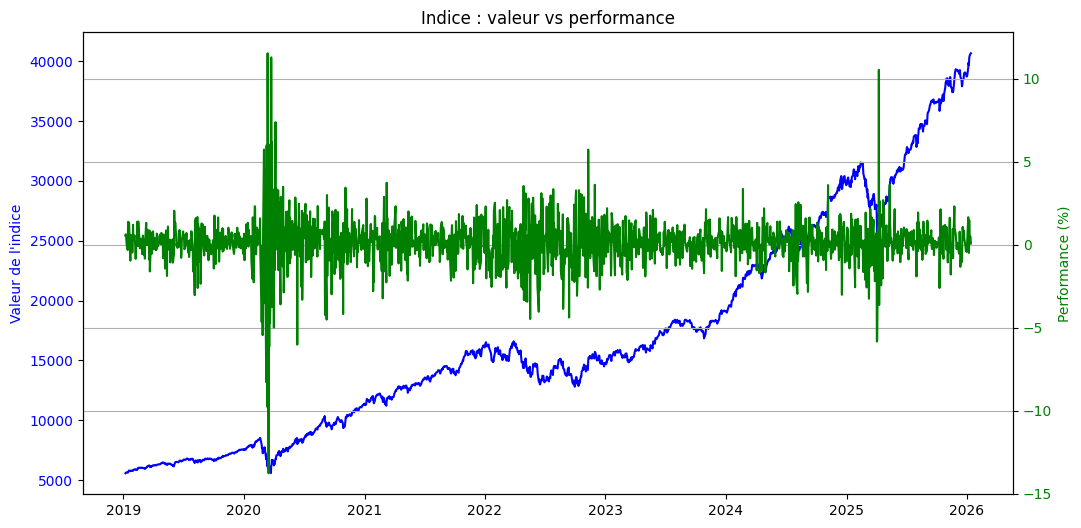

In [4]:
bt.plot_returns()

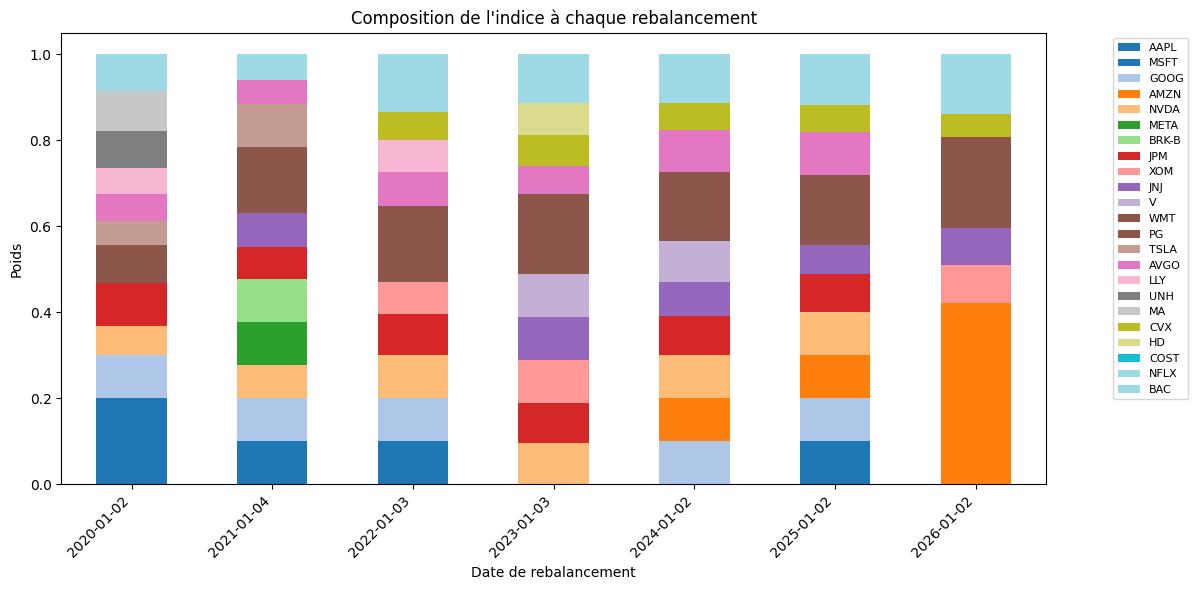

Total return                 = 629.59%
Compound Annual Growth Rate  = 32.74%
Annual Volatility            = 22.08%
Maximum Drawdown             = 34.56%


In [5]:
bt.plot_weights()
bt.compute_metrics()

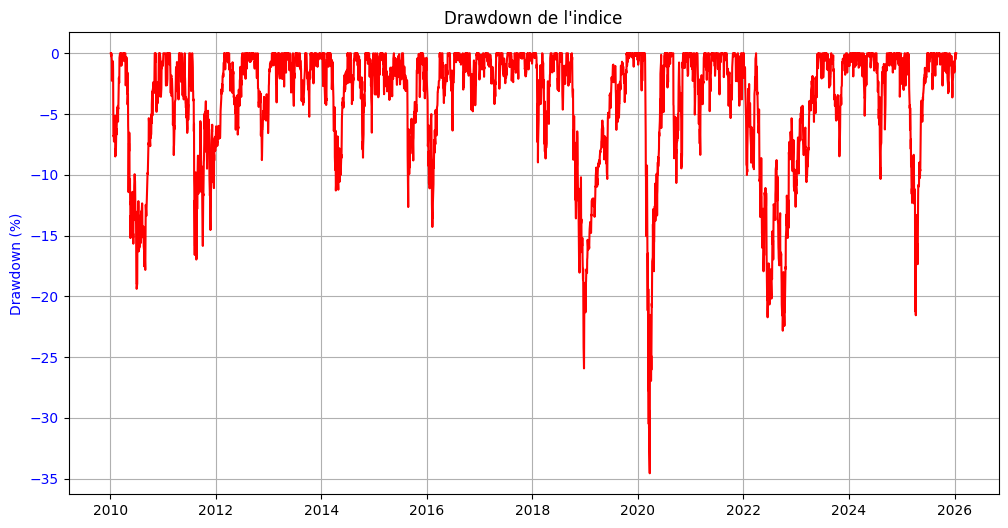

In [6]:
bt.plot_drawdown()

In [ ]:
rg = ReportGenerator(bt)
rg.to_html()
rg.to_pdf()

In [8]:
ix.constituents()

Amazon               0.420544
Exxon Mobil          0.089607
Johnson & Johnson    0.085814
Walmart              0.155527
Procter & Gamble     0.056804
Chevron              0.053537
Netflix              0.066964
Bank of America      0.071203
dtype: float64